### 04 Geometry Correction

Run geometry correction for reconstructed TEMPEST image batches.

This notebook:
1. Loads geometry correction configuration
2. Runs batch correction on reconstructed image outputs
3. Summarizes correction status
4. Provides a quick inspection entry for corrected results

In [12]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("PROJECT_ROOT =", project_root)
print("SRC_DIR      =", src_dir)

PROJECT_ROOT = E:\UsersData\Desktop\tempest_batch
SRC_DIR      = E:\UsersData\Desktop\tempest_batch\src


#### Imports

Import geometry correction modules and default parameter sets.

In [13]:
import importlib
import pandas as pd
from IPython.display import display
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import geom.geom_io as geom_io
import geom.geom_batch as geom_batch
import geom.geom_shear as geom_shear
import geom.geom_anchor as geom_anchor

importlib.reload(geom_io)
importlib.reload(geom_batch)
importlib.reload(geom_shear)
importlib.reload(geom_anchor)

from geom.geom_io import load_json
from geom.geom_batch import run_geometry_correction_batch
from geom.geom_shear import DEFAULT_SHEAR_PARAMS
from geom.geom_anchor import DEFAULT_ANCHOR_PARAMS, detect_anchors_for_image

print("geom_io    :", geom_io.__file__)
print("geom_batch :", geom_batch.__file__)
print("geom_shear :", geom_shear.__file__)
print("geom_anchor:", geom_anchor.__file__)

geom_io    : E:\UsersData\Desktop\tempest_batch\src\geom\geom_io.py
geom_batch : E:\UsersData\Desktop\tempest_batch\src\geom\geom_batch.py
geom_shear : E:\UsersData\Desktop\tempest_batch\src\geom\geom_shear.py
geom_anchor: E:\UsersData\Desktop\tempest_batch\src\geom\geom_anchor.py


#### Load Configuration

Load the default geometry correction config from `configs/geom/geom_default.json`.

The shear slope mode is controlled by:

- `"s0_mode": "fixed"`: use `fixed_s0`
- `"s0_mode": "per_slide"`: estimate one slope per slide
- `"s0_mode": "per_batch"`: estimate one shared slope per batch

In [14]:
cfg_path = project_root / "configs" / "geom" / "geom_default.json"
cfg = load_json(cfg_path)
cfg

{'input_root_dir': 'E:/UsersData/Desktop/tempest_batch/outputs',
 'batch_dir_glob': 'output_*',
 'slide_dir_glob': 'slide*',
 'geometry_source_suffix': '_stack_vertical_f0_3_amp.png',
 'variant_suffixes': {'iq': '_stack_vertical_f0_3.png',
  'amp': '_stack_vertical_f0_3_amp.png',
  'amp_gain': '_stack_vertical_f0_3_amp_gain.png',
  'amp_log_gain': '_stack_vertical_f0_3_amp_log_gain.png'},
 'frame_width': 2200,
 'frame_height': 1125,
 's0_mode': 'per_slide',
 'fixed_s0': 0.036313895136117935,
 'export_blocks': [0],
 'save_geometry_json': True,
 'save_before_shear': False,
 'overwrite': True,
 'limit_batches': 1,
 'limit_slides_per_batch': 10}

#### Optional Overrides

Apply temporary overrides for this notebook run only.

Typical debug options:
- limit the number of batches
- limit the number of slides per batch
- enable saving `before_shear`

In [15]:
# Optional notebook-only overrides
#
# Shear slope modes:
# - "fixed"     : use cfg["fixed_s0"]
# - "per_slide" : estimate s0 separately for each slide
# - "per_batch" : estimate one shared s0 for each batch
#
# Typical debug examples:
# cfg["s0_mode"] = "fixed"
# cfg["fixed_s0"] = 0.036313895136117935
#
# cfg["s0_mode"] = "per_slide"
#
# cfg["s0_mode"] = "per_batch"
#
# cfg["limit_batches"] = 1
# cfg["limit_slides_per_batch"] = 3
# cfg["save_before_shear"] = True
# cfg["export_blocks"] = [0]

cfg

{'input_root_dir': 'E:/UsersData/Desktop/tempest_batch/outputs',
 'batch_dir_glob': 'output_*',
 'slide_dir_glob': 'slide*',
 'geometry_source_suffix': '_stack_vertical_f0_3_amp.png',
 'variant_suffixes': {'iq': '_stack_vertical_f0_3.png',
  'amp': '_stack_vertical_f0_3_amp.png',
  'amp_gain': '_stack_vertical_f0_3_amp_gain.png',
  'amp_log_gain': '_stack_vertical_f0_3_amp_log_gain.png'},
 'frame_width': 2200,
 'frame_height': 1125,
 's0_mode': 'per_slide',
 'fixed_s0': 0.036313895136117935,
 'export_blocks': [0],
 'save_geometry_json': True,
 'save_before_shear': False,
 'overwrite': True,
 'limit_batches': 1,
 'limit_slides_per_batch': 10}

#### Anchor Debug (Optional)

Use this section to inspect one failed slide before running the full batch.

This debug view compares:
- all horizontal peaks
- filtered major peaks
- resulting block segmentation
- detected anchors

In [16]:
# ---- Edit for the current failed case ----
img_path = Path(
    r"E:\UsersData\Desktop\tempest_batch\outputs\output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419\slide003\slide003_stack_vertical_f0_3_amp.png"
)
s0 = 0.036592740565538406

anchor_params_debug = DEFAULT_ANCHOR_PARAMS.copy()
anchor_params_debug["major_peak_ratio"] = 0.60
anchor_params_debug["max_major_horizontal_peaks"] = 4

res_dbg = detect_anchors_for_image(
    img_path=img_path,
    s0=s0,
    params=anchor_params_debug,
    blur_sigma=1.0,
)

print("img_path       :", img_path)
print("s0             :", s0)
print("all peaks      :", res_dbg["peaks_all"])
print("filtered peaks :", res_dbg["peaks"])
print("num blocks     :", len(res_dbg["blocks"]))
print("blocks         :", res_dbg["blocks"])

for br in res_dbg["block_results"]:
    ar = br["anchor_res"]
    if ar is None:
        print(br["block_id"], br["block"], "anchor_res = None")
    else:
        print(
            br["block_id"],
            br["block"],
            "y_top =", ar["y_top"],
            "b =", round(ar["b"], 3),
            "side =", ar["side"],
            "polarity =", ar["polarity"],
            "score =", round(ar["score"], 4),
            "A_crop =", tuple(round(v, 2) for v in ar["A_crop"]),
        )

img_path       : E:\UsersData\Desktop\tempest_batch\outputs\output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419\slide003\slide003_stack_vertical_f0_3_amp.png
s0             : 0.036592740565538406
all peaks      : [  20  542 1016 1667 2222 2792 3347 3917 4472]
filtered peaks : [ 542 1667 2792 3917]
num blocks     : 3
blocks         : [(542, 1667), (1667, 2792), (2792, 3917)]
0 (542, 1667) y_top = 588 b = 1951.0 side = right polarity = -1 score = 1.9903 A_crop = (1988.52, 572.0)
1 (1667, 2792) y_top = 1713 b = 1951.0 side = right polarity = -1 score = 1.9974 A_crop = (2029.68, 1697.0)
2 (2792, 3917) y_top = 2838 b = 1951.0 side = right polarity = -1 score = 2.0043 A_crop = (2070.85, 2822.0)


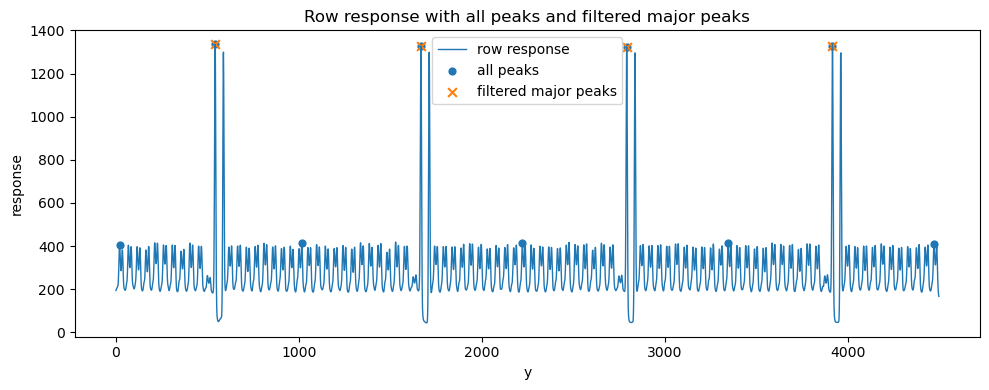

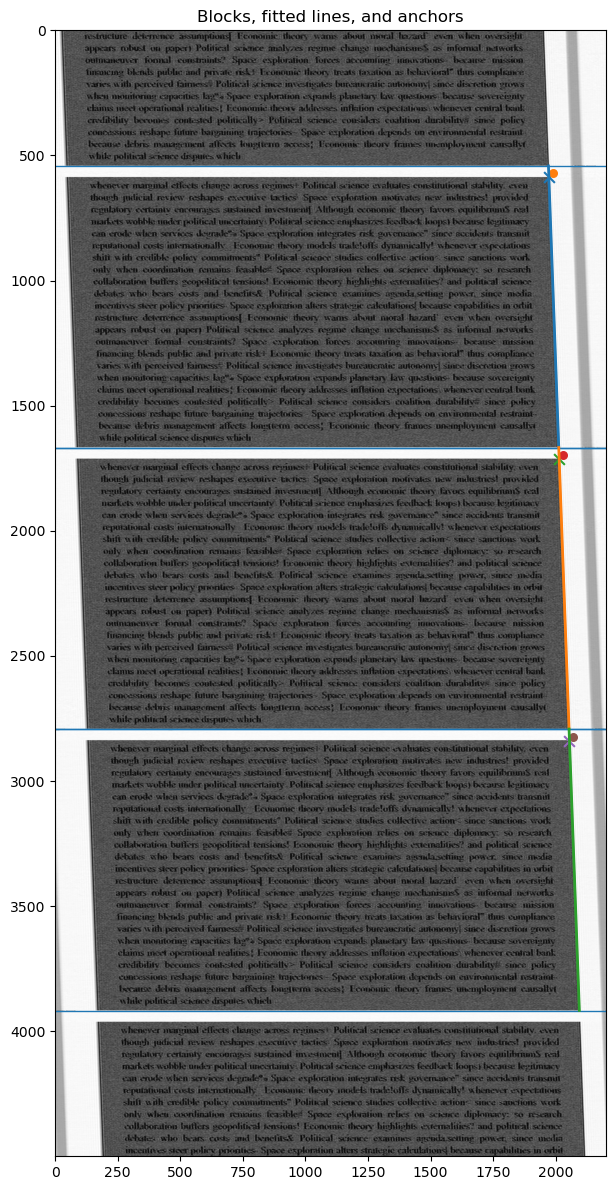

In [17]:
img = res_dbg["img"]
row_resp = res_dbg["row_resp"]
peaks_all = np.asarray(res_dbg["peaks_all"])
peaks = np.asarray(res_dbg["peaks"])
blocks = res_dbg["blocks"]
block_results = res_dbg["block_results"]
s0 = res_dbg["s0"]

# ---------- Figure 1: row response and peak comparison ----------
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(row_resp)), row_resp, linewidth=1.0, label="row response")

if len(peaks_all) > 0:
    plt.scatter(peaks_all, row_resp[peaks_all], s=24, label="all peaks")

if len(peaks) > 0:
    plt.scatter(peaks, row_resp[peaks], s=40, marker="x", label="filtered major peaks")

plt.title("Row response with all peaks and filtered major peaks")
plt.xlabel("y")
plt.ylabel("response")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Figure 2: blocks, fitted lines, and anchors ----------
plt.figure(figsize=(7, 12))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title("Blocks, fitted lines, and anchors")

for br in block_results:
    block_id = br["block_id"]
    y0, y1 = br["block"]

    plt.axhline(y0, linewidth=1)
    plt.axhline(y1, linewidth=1)

    ar = br["anchor_res"]
    if ar is None:
        continue

    b = ar["b"]
    ys = np.array([y0, y1 - 1], dtype=np.float32)
    xs = s0 * ys + b
    plt.plot(xs, ys, linewidth=2)

    x_crop, y_crop = ar["A_crop"]
    x_ref, y_ref = ar["A_ref"]

    plt.scatter([x_ref], [y_ref], marker="x", s=60)
    plt.scatter([x_crop], [y_crop], marker="o", s=30)

plt.xlim(0, img.shape[1] - 1)
plt.ylim(img.shape[0] - 1, 0)
plt.tight_layout()
plt.show()

#### Run Geometry Correction

Run correction on all discovered batch folders under `input_root_dir`.

In [18]:
summary = run_geometry_correction_batch(
    config=cfg,
    shear_params=DEFAULT_SHEAR_PARAMS,
    anchor_params=DEFAULT_ANCHOR_PARAMS,
)

len(summary)

[geom] ===== Geometry Correction Config =====
[geom] input_root_dir          = E:/UsersData/Desktop/tempest_batch/outputs
[geom] batch_dir_glob          = output_*
[geom] slide_dir_glob          = slide*
[geom] geometry_source_suffix  = _stack_vertical_f0_3_amp.png
[geom] variant_suffixes        = {'iq': '_stack_vertical_f0_3.png', 'amp': '_stack_vertical_f0_3_amp.png', 'amp_gain': '_stack_vertical_f0_3_amp_gain.png', 'amp_log_gain': '_stack_vertical_f0_3_amp_log_gain.png'}
[geom] frame_width             = 2200
[geom] frame_height            = 1125
[geom] s0_mode                 = per_slide
[geom] fixed_s0                = 0.036313895136117935
[geom] export_blocks           = [0]
[geom] save_geometry_json      = True
[geom] save_before_shear       = False
[geom] overwrite               = True
[geom] limit_batches           = 1
[geom] limit_slides_per_batch  = 10
[geom] =====================================
[geom] found 1 batch directories
[geom]   batch[1] = output_16x9_20pt_pages_0501

Geometry batches:   0%|          | 0/1 [00:00<?, ?it/s]

[geom] batch = output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419, slides = 10


output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419:   0%|          | 0/10 [00:00<?, …

[geom] summary saved to: E:\UsersData\Desktop\tempest_batch\outputs\geom_batch_summary.csv


10

#### Summary Table

Convert the returned summary list into a DataFrame for inspection.

In [19]:
df_summary = pd.DataFrame(summary)
display(df_summary.head(20))

,batch_dir,slide_id,status,s0_mode,geometry_source,s0,n_detected_blocks,n_export_blocks,n_variant_images,n_exported_files
0,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide001,ok,per_slide,slide001_stack_vertical_f0_3_amp.png,0.036628,3,1,4,4
1,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide002,ok,per_slide,slide002_stack_vertical_f0_3_amp.png,0.036591,3,1,4,4
2,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide003,ok,per_slide,slide003_stack_vertical_f0_3_amp.png,0.036593,3,1,4,4
3,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide004,ok,per_slide,slide004_stack_vertical_f0_3_amp.png,0.036544,3,1,4,4
4,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide005,ok,per_slide,slide005_stack_vertical_f0_3_amp.png,0.036527,3,1,4,4
5,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide006,ok,per_slide,slide006_stack_vertical_f0_3_amp.png,0.036645,3,1,4,4
6,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide007,ok,per_slide,slide007_stack_vertical_f0_3_amp.png,0.036737,3,1,4,4
7,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide008,ok,per_slide,slide008_stack_vertical_f0_3_amp.png,0.036705,3,1,4,4
8,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide009,ok,per_slide,slide009_stack_vertical_f0_3_amp.png,0.036760,3,1,4,4
9,output_16x9_20pt_pages_0501-0600_CF_742.500MHz...,slide010,ok,per_slide,slide010_stack_vertical_f0_3_amp.png,0.036618,3,1,4,4


#### Status Overview

Check how many slides were processed successfully, skipped, or failed.

In [20]:
display(df_summary["status"].value_counts(dropna=False))
display(df_summary.groupby("batch_dir").size())

status
ok    10
Name: count, dtype: int64

batch_dir
output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419    10
dtype: int64

#### Quick Result Inspection

Automatically select one successful slide from `df_summary` and preview
the exported corrected images.

In [24]:
# Pick the first successfully processed slide automatically
ok_row = df_summary[df_summary["status"] == "ok"].iloc[0]

slide_dir = project_root / "outputs" / ok_row["batch_dir"] / ok_row["slide_id"]
slide_id = ok_row["slide_id"]

print("batch_dir =", ok_row["batch_dir"])
print("slide_id  =", slide_id)
print("slide_dir =", slide_dir)
print("exists    =", slide_dir.exists())

sorted([p.name for p in slide_dir.glob(f"{slide_id}_block0*.png")])


batch_dir = output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419
slide_id  = slide001
slide_dir = E:\UsersData\Desktop\tempest_batch\outputs\output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419\slide001
exists    = True


['slide001_block0_amp.png',
 'slide001_block0_amp_gain.png',
 'slide001_block0_amp_log_gain.png',
 'slide001_block0_iq.png']

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = slide_dir / f"{slide_id}_block0_amp.png"
print("img_path =", img_path)
print("exists   =", img_path.exists())

img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 4))
plt.imshow(img, cmap="gray")
plt.title(img_path.name)
plt.axis("off")
plt.show()

#### Geometry JSON Preview

Inspect the saved geometry metadata for the selected slide.

In [22]:
ok_row = df_summary[df_summary["status"] == "ok"].iloc[0]

slide_dir = project_root / "outputs" / ok_row["batch_dir"] / ok_row["slide_id"]
print("slide_dir =", slide_dir)

geom_json_path = slide_dir / f'{ok_row["slide_id"]}_blocks_geom.json'
print("geom_json_path =", geom_json_path)
print("exists =", geom_json_path.exists())

geom_data = load_json(geom_json_path)
geom_data

slide_dir = E:\UsersData\Desktop\tempest_batch\outputs\output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419\slide001
geom_json_path = E:\UsersData\Desktop\tempest_batch\outputs\output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419\slide001\slide001_blocks_geom.json
exists = True


{'batch_dir': 'output_16x9_20pt_pages_0501-0600_CF_742.500MHz_FS_61.440MSPS_20260405_150419',
 'slide_id': 'slide001',
 'geometry_source': 'slide001_stack_vertical_f0_3_amp.png',
 'frame_width': 2200,
 'frame_height': 1125,
 's0': 0.03662848100066185,
 's0_mode': 'per_slide',
 'blocks': [{'block_id': 0,
   'block': [564, 1689],
   'A_ref': [38.30674492940307, 609.0],
   'A_crop': [54.30674492940307, 593.0],
   'start_index': 1304654,
   'y_top': 609,
   'b': 16.0,
   'side': 'left',
   'polarity': -1,
   'score': 2.0097460746765137},
  {'block_id': 1,
   'block': [1689, 2814],
   'A_ref': [79.51378605514765, 1734.0],
   'A_crop': [95.51378605514765, 1718.0],
   'start_index': 3779696,
   'y_top': 1734,
   'b': 16.0,
   'side': 'left',
   'polarity': -1,
   'score': 2.006692409515381},
  {'block_id': 2,
   'block': [2814, 3939],
   'A_ref': [120.72082718089223, 2859.0],
   'A_crop': [136.72082718089223, 2843.0],
   'start_index': 6254737,
   'y_top': 2859,
   'b': 16.0,
   'side': 'left

#### Notes

Recommended workflow:
1. Start with debug limits enabled
2. Verify one batch and a few slides
3. Disable limits for the full run
4. Use the summary CSV and this notebook for inspection